<a href="https://colab.research.google.com/github/sougat23bai11043-code/AI-ML-Assignments-and-Projects/blob/main/Adult_Census_Income_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Census Income Classification

## Machine Learning Project

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving adult.csv.zip to adult.csv.zip


In [ ]:
df = pd.read_csv("adult.csv.zip")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])

In [ ]:
X = df.drop("income", axis=1)

y = df["income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.2,
                  random_state=42
                  )

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(
      n_estimators=100,
          random_state=42
          )

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8544449562413634


In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.7298985167837627


In [ ]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.6083279115159401


In [ ]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.6635911994322214


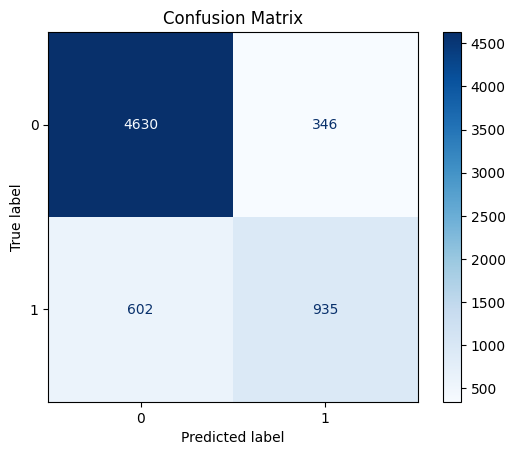

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4976
           1       0.73      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



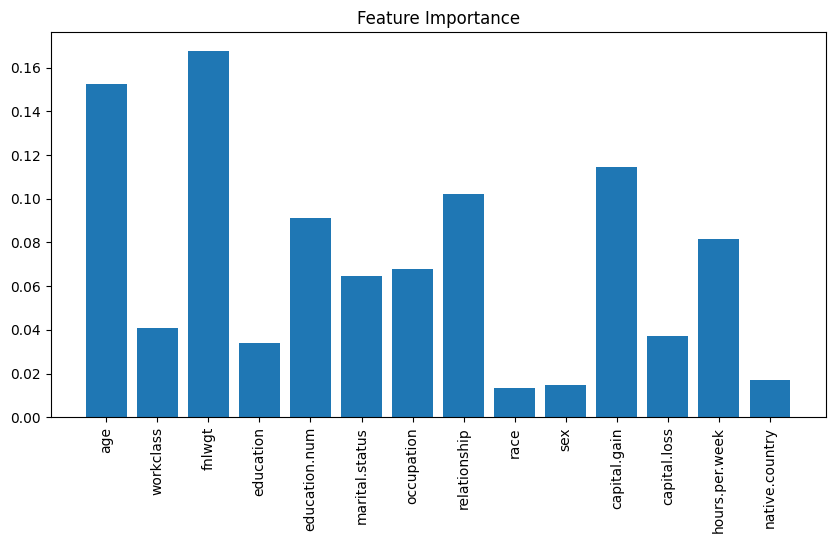

In [ ]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

## Observations

1. The Random Forest classifier successfully predicted whether a person's income is above or below the threshold.

2. The model achieved good classification accuracy on the test dataset.

3. The confusion matrix showed that most income categories were classified correctly.

4. Feature importance analysis identified the most influential attributes affecting income prediction.

## Conclusion

In this project, the Adult Census Income dataset was used to build a Random Forest classification model. The dataset was preprocessed by encoding categorical variables, handling missing values, and scaling the features before splitting it into training and testing sets. The trained model was evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. The Random Forest classifier produced good prediction performance and identified the most important features influencing income classification. This project demonstrates how machine learning can be applied to predict income categories using demographic and employment-related information.